In [1]:
import sys
sys.path.append('..')
from utils.fonctions import load_parquet_data, normalize_colnames_list
from src.artifacts.data_processing import Nettoyage
from utils.fonctions import load_pickle
import numpy as np

TARGET_COL = 'consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'

def numerize(data, encoding_pipeline, downcast_num_cols=True):

    def downcast_numeric_cols():
        # int32 range = 2**32/2 à gauche et à droite de 0
        for c in data.columns:
            if data[c].dtype == 'int64':
                data[c] = data[c].astype('int32')
            elif data[c].dtype == 'float64':
                data[c] = data[c].astype('float32')
        return data
    
    encoding_pipeline.set_output(transform='pandas')
    data = encoding_pipeline.fit_transform(data)

    if downcast_num_cols:
        return downcast_numeric_cols()
    return data

In [2]:
# import data frame 2022
df = load_parquet_data('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')
pipeline = Nettoyage(df)

pipeline.run(use_entropy_selection = True)
df_clean_v1 = pipeline.df

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..
-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 250 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 55 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 145 colonnes et 375231 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !
Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['conso_5_usages_e_finale_energie_ndeg1_ademe', 'conso_chauffage_e_finale_ademe', 'conso_5_usages_e_finale_ademe', 'besoin_ecs_ademe', 'conso_refroidissement_depensier_e_primaire_ademe', 'conso_e_finale_depensier_generateur_ecs_ndeg1_ademe', 'surface_chauffee_installation_chauffage_ndeg1_ademe', 'emission_ges_ecs_ademe', 'emission_ges_auxiliaires_ademe', 'emission_ges_ecs_energie_ndeg1_a

In [3]:
# make encoding pipeline

categorical_encoder = load_pickle('../ressources/encoders_fitted/categorical_encoders.pkl')
categorical_encoder

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal_encoding',
                                 OrdinalEncoder(mapping=[{'col': 'qualite_isolation_menuiseries_ademe',
                                                          'data_type': dtype('O'),
                                                          'mapping': insuffisante    1
moyenne         2
bonne           3
très bonne      4
<NA>           -1
dtype: int64},
                                                         {'col': 'qualite_isolation_murs_ademe',
                                                          'data_type': dtype('O'),
                                                          'mapping': insuffisante    1
moyenne         2
bonne           3
très bonne      4
<NA>           -1
dt...
                                  'type_energie_principale_ecs_ademe',
                                  'type_energie_ndeg1_ademe',
                                  'type_installation_ecs_ademe',
                                  'type_enedis_with_ban',
                                  'type_installation_chauffage_ndeg1_ademe',
                                  'type_energie_ndeg2_ademe',
                                  'type_installation_ecs_general_ademe',
                                  'methode_application_dpe_ademe',
                                  'configuration_installation_ecs_ademe',
                                  'type_generateur_ecs_ndeg1_ademe'])],
                  verbose_feature_names_out=False)

In [ ]:
# new_pipeline =  # nouveau pipeline avec standard scaler mais avce étape categ encoders

In [4]:
df = numerize(df_clean_v1, categorical_encoder)

# Stat desc

* conso / deperdition t caractéristiques des logements
* distribution des logements en focntion du DPE
* consommation électrique en focntion du DPE


# Modelisation

In [ ]:
# consommation électrique et impact de chaque varibles, natamment l'importance du DPE
# modèle d'arbre
# regression lineaire : ridge lasso
# modèle de boosting

# part de la consommation / de la déperdition d'énergie et importantce du DPE

# 1. modèle d'arbre

In [5]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error


# séparation des données en target Y et features X
x = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# séparation des données en train et test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=25)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((295264, 87), (73817, 87), (295264,), (73817,))

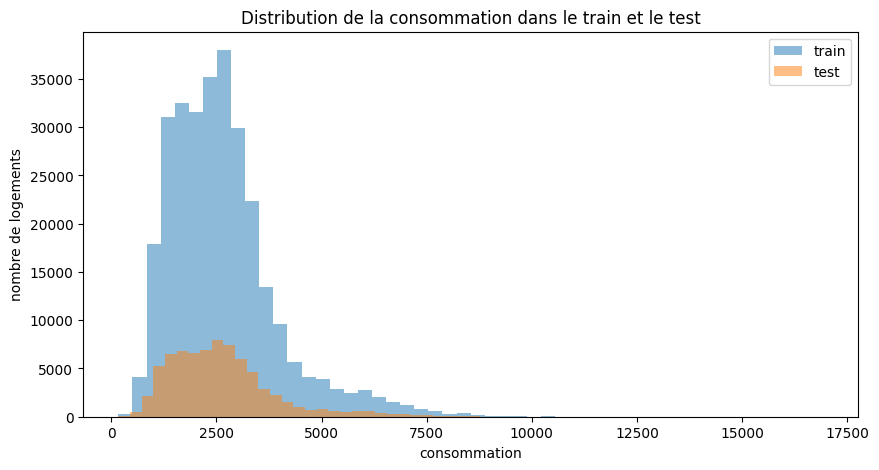

<Figure size 640x480 with 0 Axes>

In [6]:
# graphique de la distribution de la consommation dans le train et le test
plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=50, alpha=0.5, label='train')
plt.hist(y_test, bins=50, alpha=0.5, label='test')
plt.xlabel('consommation')
plt.ylabel('nombre de logements')
plt.title('Distribution de la consommation dans le train et le test')
plt.legend()
plt.show()
# y_train.describe(), y_test.describe()
plt.savefig('../ressources/img/distribution_consommation_train_test_carla.png')

In [ ]:
# apprentissage du modèle par validation croisée avec grid search
# DT = DecisionTreeRegressor()

# clf_dt = GridSearchCV(DT, cv=5, param_grid={'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
#                                             'max_depth': [3, 5, 7, 9, 11],
#                                             'splitter':["best", "random"]})


# apprentissage du modèle par validation croisée avec randomized search
# clf_dt = RandomizedSearchCV(DT, cv=5, param_distributions={'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
#                                             'max_depth': [3, 5, 7, 9, 11],
#                                             'splitter':["best",
#     


In [ ]:
# apprentissage du modèle 
DT = DecisionTreeRegressor()

mdl_dt = DT.fit(x_train, y_train)
y_pred = mdl_dt.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse, mape, r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(622664.0017882059, 0.16527461646755634, 0.623219190956817, 789.0906169688028)

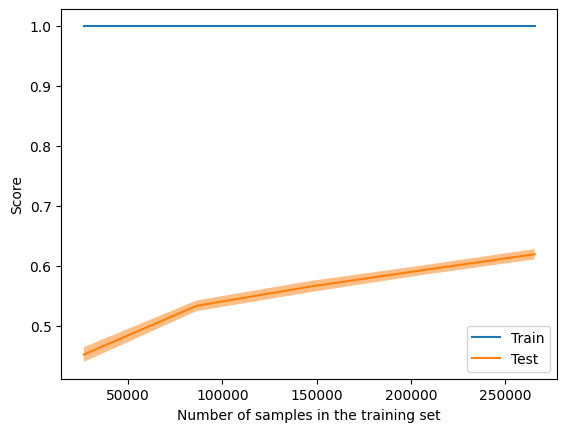

In [ ]:
# courbe d'apprentissage 
from sklearn.model_selection import learning_curve, LearningCurveDisplay

train_sizes, train_scores, test_scores = learning_curve(
   DT, x_train, y_train, cv=10)

display = LearningCurveDisplay(train_sizes=train_sizes,
   train_scores=train_scores, test_scores=test_scores, score_name="Score")

display.plot()
plt.show()
plt.savefig('../ressources/img/learning_curve_DT1_carla.png')

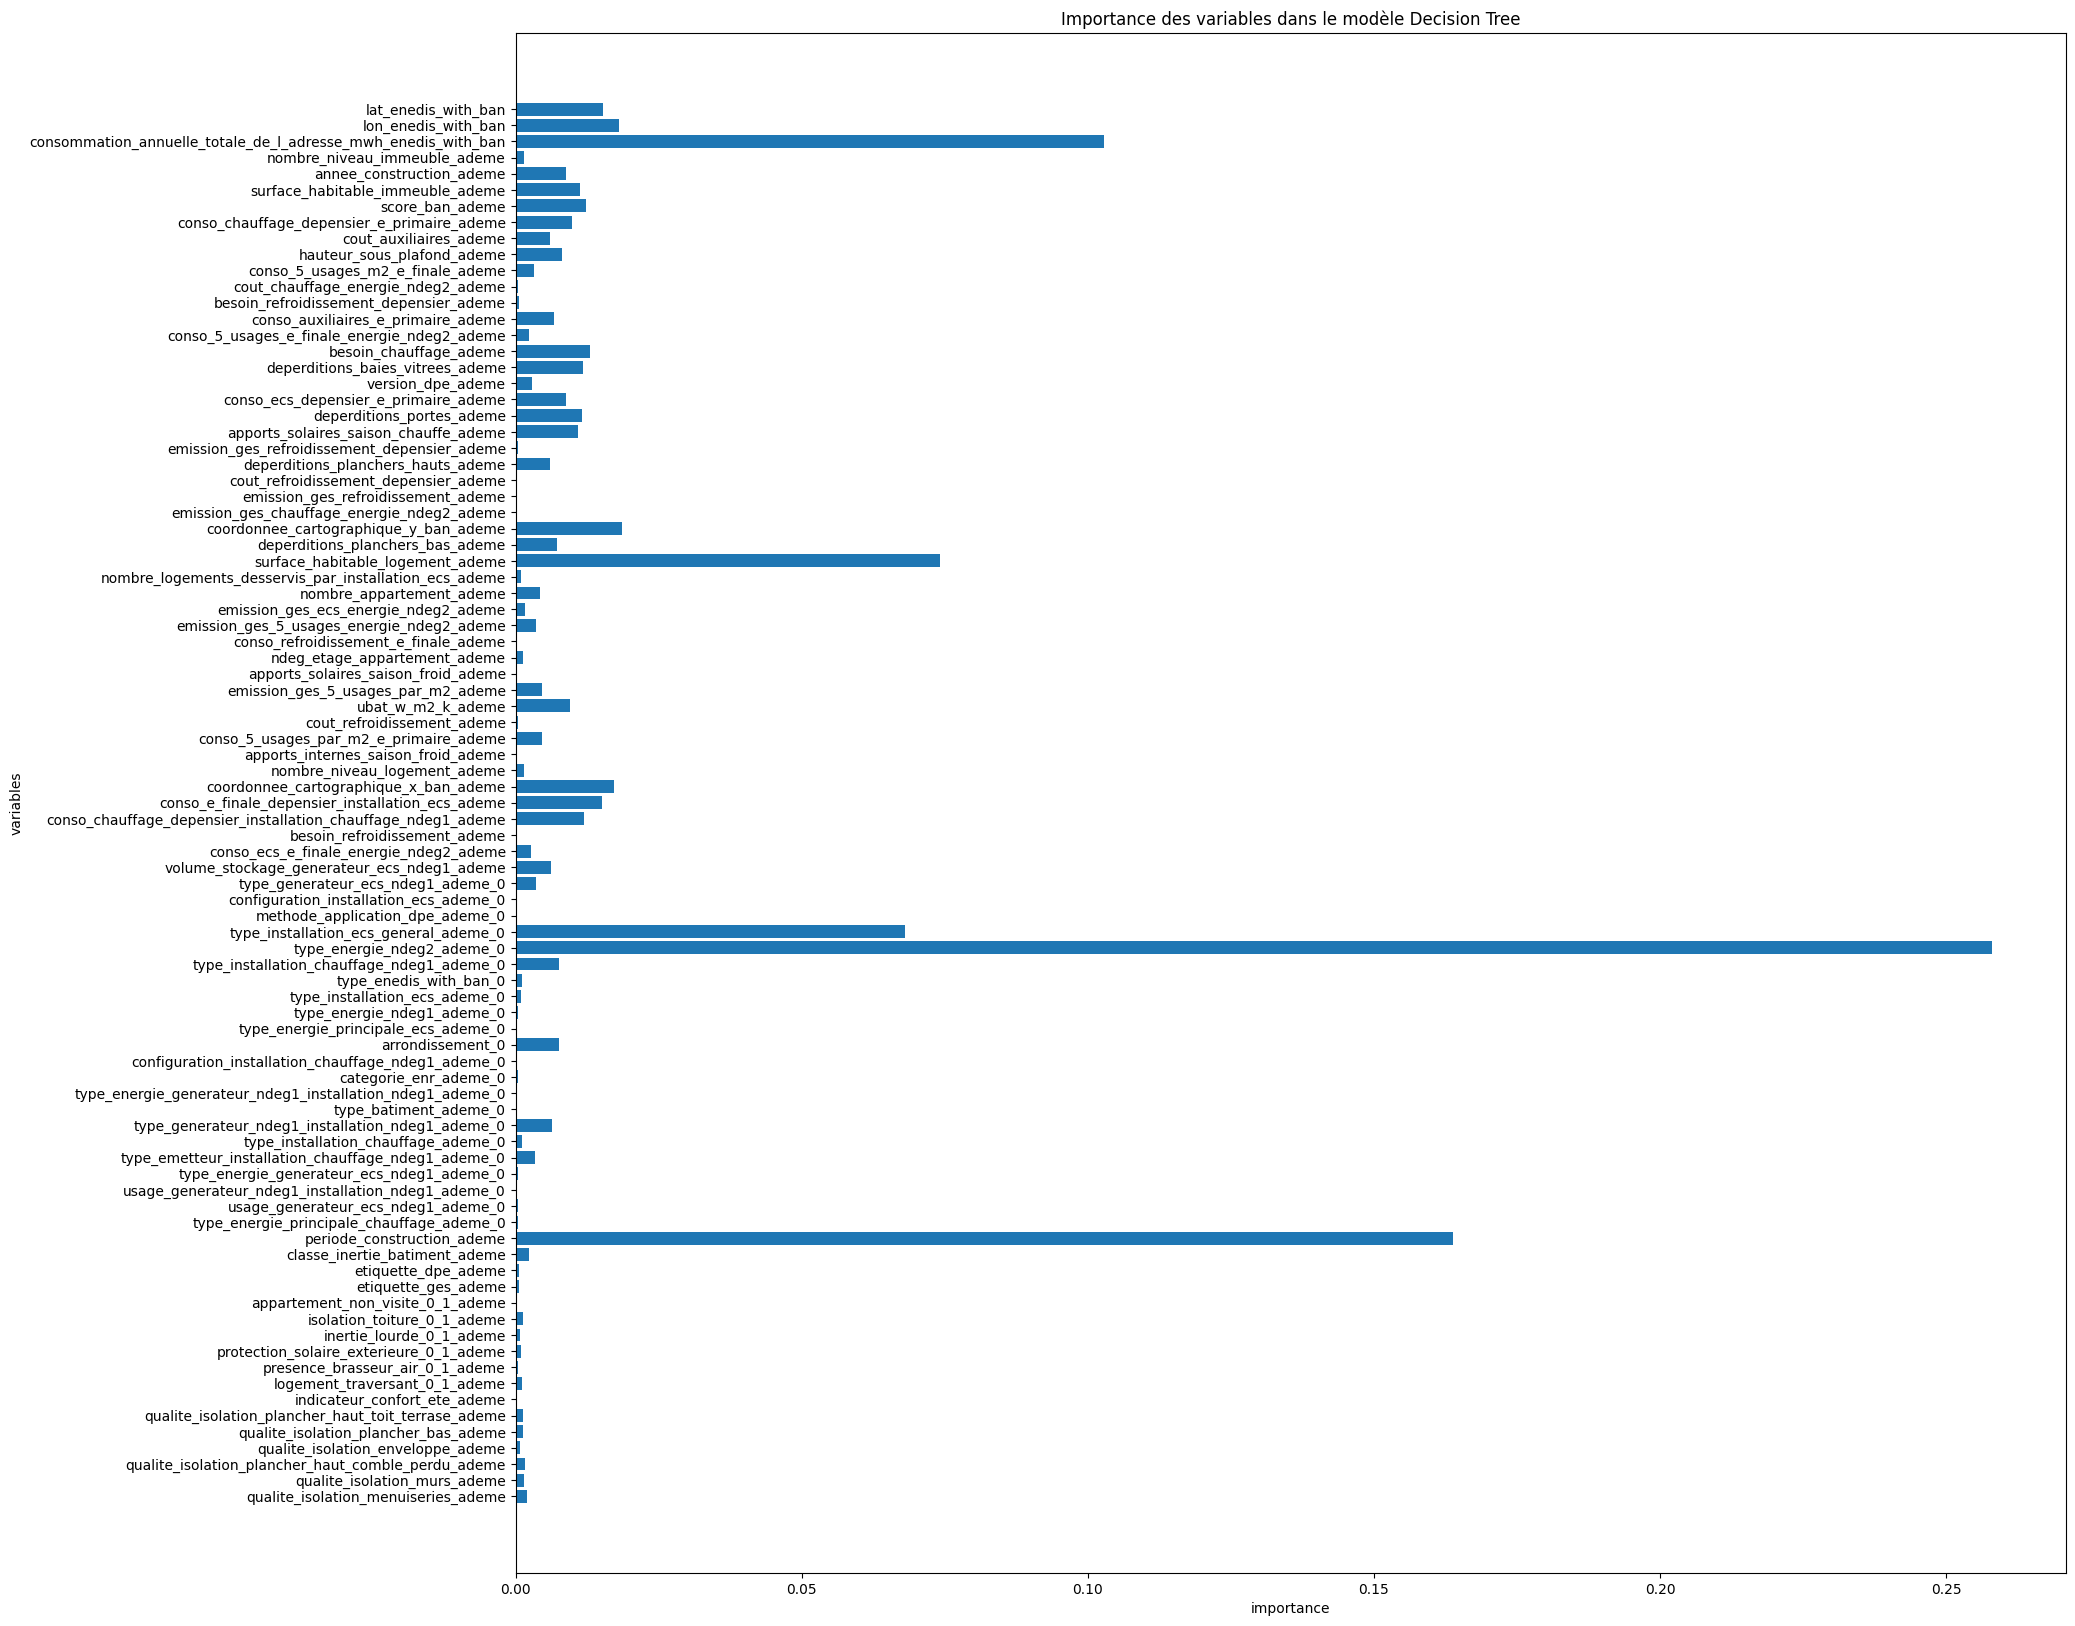

In [ ]:
DT.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, DT.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree v1')
plt.show()
plt.savefig('../ressources/img/importance_variables_DT1_carla.png')

In [12]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_dt, '../ressources/models_fitted/decision_tree_model_v1_carla.pkl')


['../ressources/models_fitted/decision_tree_model_v1_carla.pkl']

Version 2 avec les hypers paramtres

In [19]:
# apprentissage du modèle avec des hyperparamètres
DT2 = DecisionTreeRegressor( random_state=25, max_depth=15)

mdl_dt2 = DT2.fit(x_train, y_train)
y_pred2 = mdl_dt2.predict(x_test)
mse2 = mean_squared_error(y_test, y_pred2)
mape2 = mean_absolute_percentage_error(y_test, y_pred2)
mse2, mape2, r2_score(y_test, y_pred2), root_mean_squared_error(y_test, y_pred2)
# avant : (622664.0017882059, 0.16527461646755634, 0.623219190956817, 789.0906169688028)
# avec 10 :(506659.12307232607, 0.20115799945796897, 0.6934150139528484, 711.799917864793)
# avec 20 :(509797.43845185597, 0.16286893446552722, 0.6915159849350538, 714.0010073185163)
# avec 15 : (474069.40312568436, 0.1743571106396366, 0.7131354105274413, 688.5269806809929)

(474069.40312568436, 0.1743571106396366, 0.7131354105274413, 688.5269806809929)

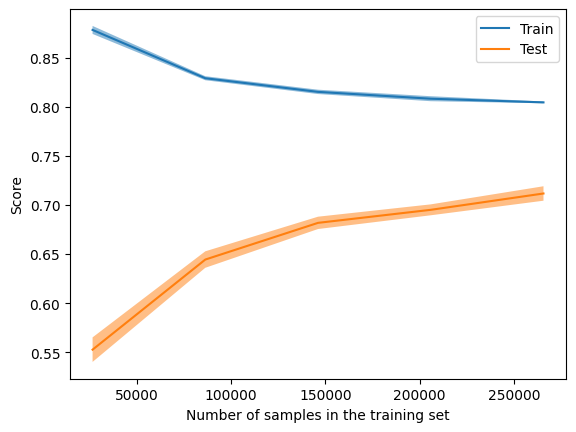

<Figure size 640x480 with 0 Axes>

In [22]:
train_sizes2, train_scores2, test_scores2 = learning_curve(DT2, x_train, y_train, cv=10)

display = LearningCurveDisplay(train_sizes=train_sizes2,train_scores=train_scores2, test_scores=test_scores2, score_name="Score")

display.plot()
plt.show()
plt.savefig('../ressources/img/learning_curve_DT2_carla.png')

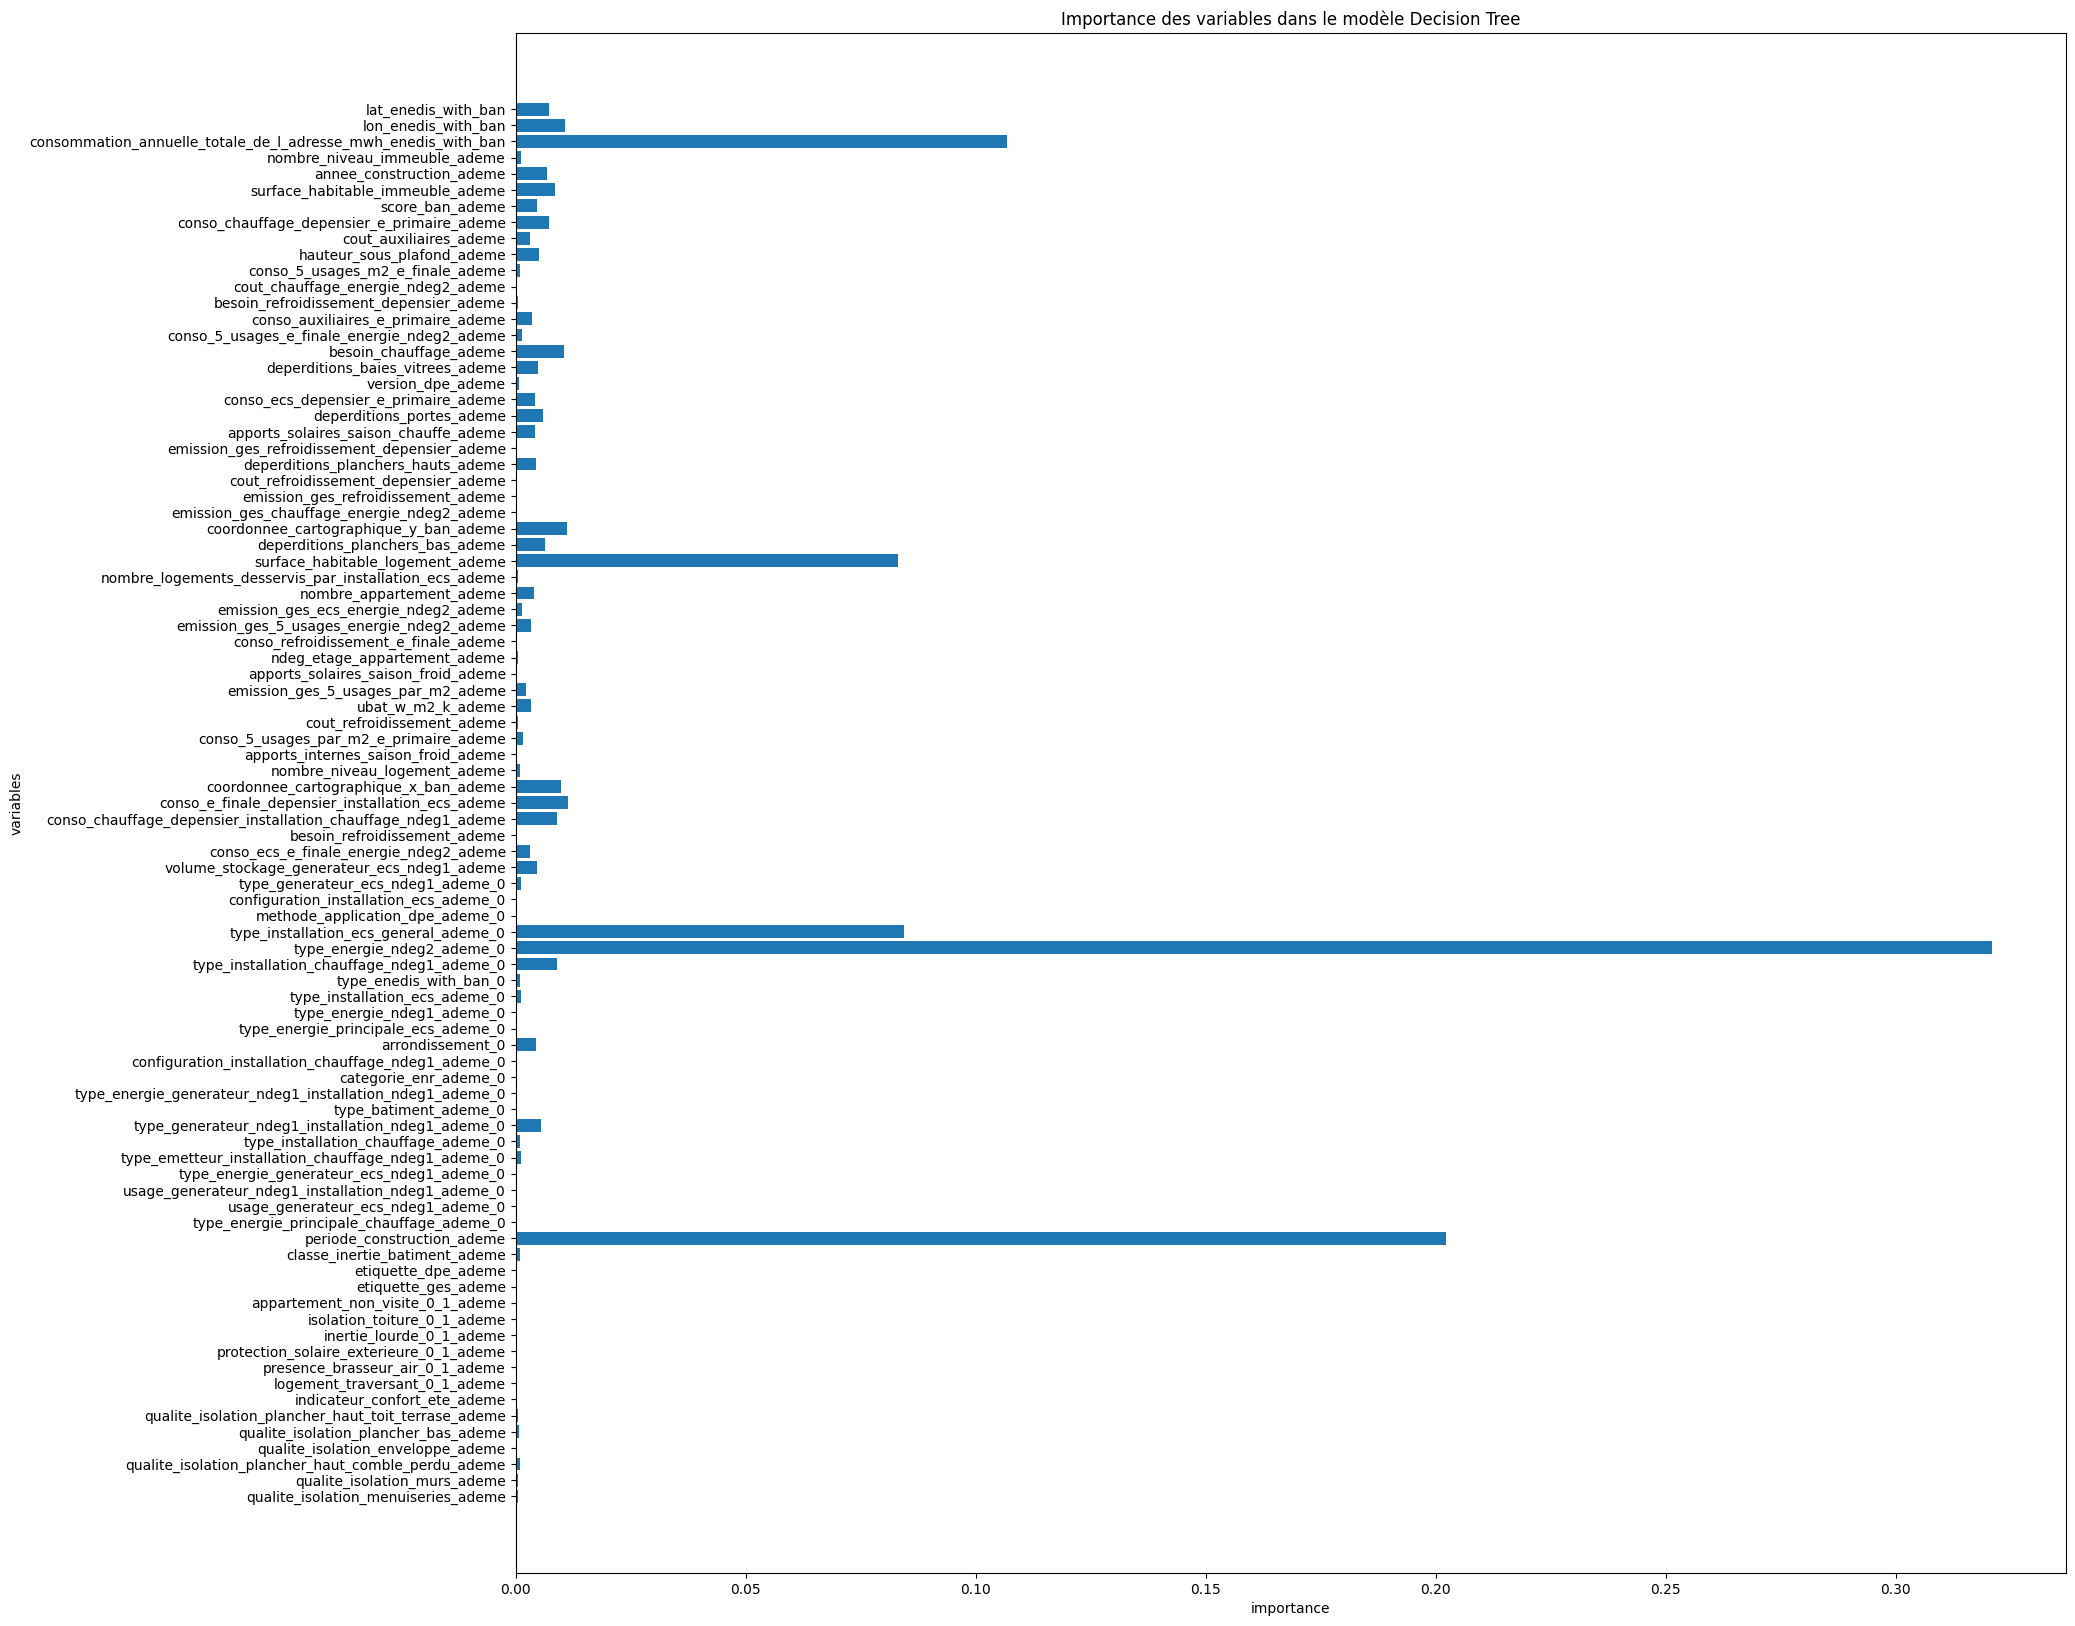

<Figure size 640x480 with 0 Axes>

In [23]:
DT2.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, DT2.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Decision Tree')
plt.show()
plt.savefig('../ressources/img/importance_variables_DT2_carla.png')

In [25]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_dt2, '../ressources/models_fitted/decision_tree_model_v2_carla.pkl')

['../ressources/models_fitted/decision_tree_model_v2_carla.pkl']

# 2.Random forest

In [26]:
# apprentissage du modèle 
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor()

mdl_rf = RF.fit(x_train, y_train)
y_pred = mdl_rf.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse, mape, r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(299958.90431082546,
 0.13203709363564678,
 0.8184915808182822,
 547.6850411603602)

In [28]:
# courbe d'apprentissage 

train_sizes, train_scores, test_scores = learning_curve(
RF, x_train, y_train, cv=5)

display = LearningCurveDisplay(train_sizes=train_sizes,
train_scores=train_scores, test_scores=test_scores, score_name="Score")

display.plot()
plt.show()
plt.savefig('../ressources/img/learning_curve_RF1_carla.png')

KeyboardInterrupt: 

In [ ]:
# barre plot de corrélation des variables avec la target
# corrélation des variables avec le DPE
# faire one hot sur les variables qualitatives et faire une PCA sur ce variables pour ne garder qu'une partie

In [ ]:
# sauvegarde du modèle
from joblib import dump 
dump(mdl_rf, '../ressources/models_fitted/randamon_forest_model_v1_carla.pkl')

In [ ]:
RF.feature_importances_
# importance des variables
plt.figure(figsize=(20, 20))
plt.barh(x.columns, RF.feature_importances_)
plt.xlabel('importance')
plt.ylabel('variables')
plt.title('Importance des variables dans le modèle Random Forest')
plt.show()
plt.savefig('../ressources/img/importance_variables_RF_carla.png')